In [ ]:
import pandas as pd

# Load your datasets
trades = pd.read_csv('/content/historical_data.csv')
sent = pd.read_csv('/content/fear_greed_index.csv')

# Convert timestamps
trades['trade_date'] = pd.to_datetime(trades['Timestamp'], errors='coerce').dt.normalize()
sent['date'] = pd.to_datetime(sent['date'], errors='coerce').dt.normalize()
sent['label'] = sent['classification'].str.strip().str.capitalize()  # 'Greed' or 'Fear'


In [ ]:
print(result.shape)
print(result['label'].value_counts())
print(result[['realized_PnL', 'n_trades']].describe())
print(result.head())

(0, 7)
Series([], Name: count, dtype: int64)
       realized_PnL  n_trades
count           0.0       0.0
mean            NaN       NaN
std             NaN       NaN
min             NaN       NaN
25%             NaN       NaN
50%             NaN       NaN
75%             NaN       NaN
max             NaN       NaN
Empty DataFrame
Columns: [trade_date, realized_PnL, n_trades, gross_notional, date, label, value]
Index: []


In [ ]:
print(trades['trade_date'].dt.date.unique())
print(sent['date'].dt.date.unique())


[datetime.date(1970, 1, 1)]
[datetime.date(2018, 2, 1) datetime.date(2018, 2, 2)
 datetime.date(2018, 2, 3) ... datetime.date(2025, 4, 30)
 datetime.date(2025, 5, 1) datetime.date(2025, 5, 2)]


In [ ]:
print(trades['trade_date'].dtype)
print(sent['date'].dtype)


datetime64[ns]
datetime64[ns]


In [ ]:
print(trades[['trade_date']].head())
print(sent[['date']].head())


  trade_date
0 2024-10-27
1 2024-10-27
2 2024-10-27
3 2024-10-27
4 2024-10-27
        date
0 2018-02-01
1 2018-02-02
2 2018-02-03
3 2018-02-04
4 2018-02-05


In [ ]:
trades['trade_date'] = pd.to_datetime(trades['trade_date']).dt.normalize()
sent['date'] = pd.to_datetime(sent['date']).dt.normalize()


In [ ]:
missing_dates = set(trades['trade_date']) - set(sent['date'])
print("Dates in trades not in sentiment:", missing_dates)


Dates in trades not in sentiment: {Timestamp('2025-06-15 00:00:00')}


In [ ]:
print(trades['Timestamp'].head(10))
print(trades['Timestamp'].isna().sum())


0    1.730000e+12
1    1.730000e+12
2    1.730000e+12
3    1.730000e+12
4    1.730000e+12
5    1.730000e+12
6    1.730000e+12
7    1.730000e+12
8    1.730000e+12
9    1.730000e+12
Name: Timestamp, dtype: float64
0


In [ ]:
# Try parsing with the detected format if you know it (e.g., '%Y-%m-%d %H:%M:%S')
trades['trade_date'] = pd.to_datetime(trades['Timestamp'], errors='coerce').dt.normalize()
print(trades[['Timestamp', 'trade_date']].head(10))


      Timestamp trade_date
0  1.730000e+12 1970-01-01
1  1.730000e+12 1970-01-01
2  1.730000e+12 1970-01-01
3  1.730000e+12 1970-01-01
4  1.730000e+12 1970-01-01
5  1.730000e+12 1970-01-01
6  1.730000e+12 1970-01-01
7  1.730000e+12 1970-01-01
8  1.730000e+12 1970-01-01
9  1.730000e+12 1970-01-01


In [ ]:
print(trades[trades['trade_date'].isna()])


Empty DataFrame
Columns: [Account, Coin, Execution Price, Size Tokens, Size USD, Side, Timestamp IST, Start Position, Direction, Closed PnL, Transaction Hash, Order ID, Crossed, Fee, Trade ID, Timestamp, trade_date]
Index: []


In [ ]:
# Correct conversion from Unix epoch milliseconds
trades['trade_date'] = pd.to_datetime(trades['Timestamp'], unit='ms').dt.normalize()

print(trades[['Timestamp', 'trade_date']].head(10))


      Timestamp trade_date
0  1.730000e+12 2024-10-27
1  1.730000e+12 2024-10-27
2  1.730000e+12 2024-10-27
3  1.730000e+12 2024-10-27
4  1.730000e+12 2024-10-27
5  1.730000e+12 2024-10-27
6  1.730000e+12 2024-10-27
7  1.730000e+12 2024-10-27
8  1.730000e+12 2024-10-27
9  1.730000e+12 2024-10-27


In [ ]:
daily_agg = trades.groupby(['trade_date']).agg({
    'Closed PnL': 'sum',
    'Account': 'count',
    'Size USD': 'sum'
})
daily_agg.rename(columns={'Account':'n_trades', 'Closed PnL':'realized_PnL', 'Size USD':'gross_notional'}, inplace=True)
daily_agg.reset_index(inplace=True)


In [ ]:
result = pd.merge(daily_agg, sent[['date', 'label', 'value']], left_on='trade_date', right_on='date', how='left')
result = result.dropna(subset=['label'])  # Only keep days with known sentiment


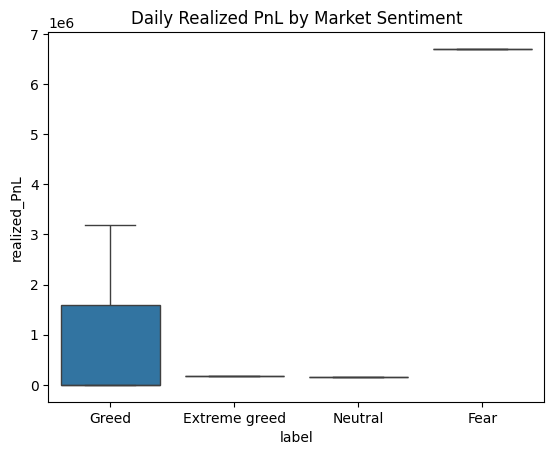

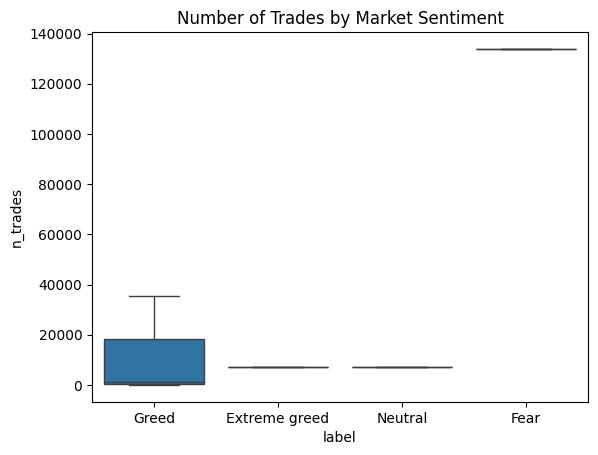

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Boxplot of PnL by Sentiment
sns.boxplot(x='label', y='realized_PnL', data=result)
plt.title('Daily Realized PnL by Market Sentiment')
plt.show()

# Boxplot of trade activity
sns.boxplot(x='label', y='n_trades', data=result)
plt.title('Number of Trades by Market Sentiment')
plt.show()


In [ ]:
print(result.groupby('label')[['realized_PnL','n_trades','gross_notional']].mean())


               realized_PnL       n_trades  gross_notional
label                                                     
Extreme greed  1.769655e+05    6962.000000    3.940677e+07
Fear           6.699925e+06  133871.000000    7.041585e+08
Greed          1.063206e+06   12096.333333    3.850122e+07
Neutral        1.587424e+05    7141.000000    2.184323e+07
